In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Create a synthetic dataset of boys and girls social media usage
np.random.seed(42)

num_users = 150

# Generate names
first_names_boys = ['Rahul', 'Amit', 'Suresh', 'Raj', 'Vikram', 'Arjun', 'Karan', 'Rohit', 'Deepak', 'Manoj']
first_names_girls = ['Priya', 'Anjali', 'Kavita', 'Neha', 'Pooja', 'Riya', 'Sneha', 'Tina', 'Veena', 'Zara']
last_names = ['Sharma', 'Verma', 'Gupta', 'Singh', 'Kumar', 'Patel', 'Jain', 'Agarwal', 'Chopra', 'Mehta']

# Generate genders
genders = np.random.choice(['Boy', 'Girl'], num_users)

# Generate names
names = []
for gender in genders:
    if gender == 'Boy':
        first = np.random.choice(first_names_boys)
    else:
        first = np.random.choice(first_names_girls)
    last = np.random.choice(last_names)
    names.append(f"{first} {last}")

# Social media usage (hours per day)
# Girls tend to use more social media than boys (typical pattern)
social_media_hours = []
for gender in genders:
    if gender == 'Girl':
        hours = np.random.normal(5.5, 1.5, 1)[0]  # Girls: mean 5.5 hours
    else:
        hours = np.random.normal(4.2, 1.5, 1)[0]  # Boys: mean 4.2 hours
    social_media_hours.append(max(0.5, hours))  # Ensure minimum 0.5 hours

# Create DataFrame
df = pd.DataFrame({
    'Name': names,
    'Gender': genders,
    'Social_Media_Hours': np.round(social_media_hours, 2)
})

print("Social Media Usage Dataset Created:")
print(df.head(10))
print(f"\nTotal Users: {len(df)}")

Social Media Usage Dataset Created:
            Name Gender  Social_Media_Hours
0   Suresh Gupta    Boy                4.00
1    Priya Kumar   Girl                4.31
2     Manoj Jain    Boy                3.65
3   Manoj Chopra    Boy                4.44
4   Karan Chopra    Boy                4.03
5     Tina Verma   Girl                6.75
6     Rahul Jain    Boy                3.72
7  Karan Agarwal    Boy                3.89
8   Vikram Gupta    Boy                4.61
9     Tina Patel   Girl                8.87

Total Users: 150


In [3]:
# Save to Excel file
excel_file = 'social_media_usage.xlsx'
df.to_excel(excel_file, index=False)
print(f"Dataset saved to {excel_file}")

Dataset saved to social_media_usage.xlsx


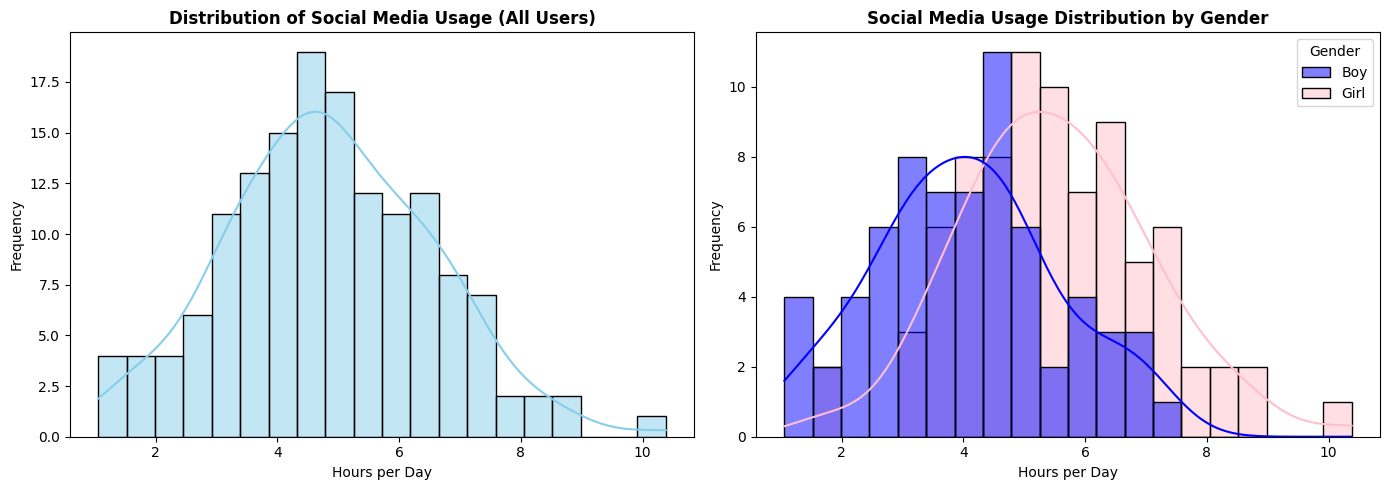

Histplot created successfully!


In [4]:
# Create histplot with KDE curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histplot for all users
ax1 = axes[0]
sns.histplot(data=df, x='Social_Media_Hours', kde=True, ax=ax1, bins=20, color='skyblue')
ax1.set_title('Distribution of Social Media Usage (All Users)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hours per Day')
ax1.set_ylabel('Frequency')

# Histplot by gender
ax2 = axes[1]
sns.histplot(data=df, x='Social_Media_Hours', kde=True, hue='Gender', ax=ax2, bins=20, palette=['blue', 'pink'])
ax2.set_title('Social Media Usage Distribution by Gender', fontsize=12, fontweight='bold')
ax2.set_xlabel('Hours per Day')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Histplot created successfully!")

In [ ]:
# Create SQLite database
db_file = 'social_media_usage.db'
conn = sqlite3.connect(db_file)
cursor = conn.cursor()

# Create table
cursor.execute('''
CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT,
    gender TEXT,
    social_media_hours REAL
)
''')

# Insert data
for _, row in df.iterrows():
    cursor.execute('''
    INSERT INTO users (name, gender, social_media_hours) VALUES (?, ?, ?)
    ''', (row['Name'], row['Gender'], row['Social_Media_Hours']))

conn.commit()
print(f"Database created and data inserted: {db_file}")

# Display table info
cursor.execute('SELECT COUNT(*) FROM users')
count = cursor.fetchone()[0]
print(f"Total records in database: {count}")

In [ ]:
# Analysis: Calculate Mean and Median
print("=" * 60)
print("ANALYSIS: SOCIAL MEDIA USAGE BY GENDER")
print("=" * 60)

# Overall statistics
overall_mean = df['Social_Media_Hours'].mean()
overall_median = df['Social_Media_Hours'].median()
overall_std = df['Social_Media_Hours'].std()

print(f"\nOverall Statistics:")
print(f"Mean Social Media Hours: {overall_mean:.2f} hours/day")
print(f"Median Social Media Hours: {overall_median:.2f} hours/day")
print(f"Standard Deviation: {overall_std:.2f}")

# Statistics by Gender
print(f"\n{'Gender':<10} {'Count':<8} {'Mean':<12} {'Median':<12} {'Std Dev':<12}")
print("-" * 54)

for gender in ['Boy', 'Girl']:
    gender_data = df[df['Gender'] == gender]['Social_Media_Hours']
    count = len(gender_data)
    mean = gender_data.mean()
    median = gender_data.median()
    std = gender_data.std()
    print(f"{gender:<10} {count:<8} {mean:<12.2f} {median:<12.2f} {std:<12.2f}")

# Difference between boys and girls
boys_mean = df[df['Gender'] == 'Boy']['Social_Media_Hours'].mean()
girls_mean = df[df['Gender'] == 'Girl']['Social_Media_Hours'].mean()
diff = girls_mean - boys_mean

print(f"\nDifference (Girls Mean - Boys Mean): {diff:.2f} hours/day")
print(f"Girls spend {diff:.2f} more hours on social media than boys on average")

In [ ]:
# Visualization: Box plot and distribution comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Box plot by gender
ax1 = axes[0, 0]
df.boxplot(column='Social_Media_Hours', by='Gender', ax=ax1)
ax1.set_title('Social Media Usage Distribution by Gender')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Hours per Day')
plt.sca(ax1)
plt.xticks(rotation=0)

# Histogram with KDE
ax2 = axes[0, 1]
boys_data = df[df['Gender'] == 'Boy']['Social_Media_Hours']
girls_data = df[df['Gender'] == 'Girl']['Social_Media_Hours']
ax2.hist(boys_data, alpha=0.5, label='Boys', bins=15, color='blue')
ax2.hist(girls_data, alpha=0.5, label='Girls', bins=15, color='pink')
ax2.set_xlabel('Hours per Day')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Social Media Usage')
ax2.legend()

# Bar plot: Mean and Median comparison
ax3 = axes[1, 0]
categories = ['Boys', 'Girls']
means = [boys_mean, girls_mean]
medians = [df[df['Gender'] == 'Boy']['Social_Media_Hours'].median(),
           df[df['Gender'] == 'Girl']['Social_Media_Hours'].median()]
x = np.arange(len(categories))
width = 0.35
ax3.bar(x - width/2, means, width, label='Mean', color='skyblue')
ax3.bar(x + width/2, medians, width, label='Median', color='lightcoral')
ax3.set_ylabel('Hours per Day')
ax3.set_title('Mean vs Median by Gender')
ax3.set_xticks(x)
ax3.set_xticklabels(categories)
ax3.legend()

# Violin plot
ax4 = axes[1, 1]
parts = ax4.violinplot([boys_data, girls_data], positions=[1, 2], showmeans=True, showmedians=True)
ax4.set_xticks([1, 2])
ax4.set_xticklabels(['Boys', 'Girls'])
ax4.set_ylabel('Hours per Day')
ax4.set_title('Violin Plot of Social Media Usage')

plt.tight_layout()
plt.show()

In [5]:
# Database queries for further analysis
print("\n" + "=" * 60)
print("DATABASE QUERIES")
print("=" * 60)

# User with highest social media usage
cursor.execute('SELECT name, gender, social_media_hours FROM users ORDER BY social_media_hours DESC LIMIT 1')
highest = cursor.fetchone()
print(f"\nHighest Usage: {highest[0]} ({highest[1]}) - {highest[2]:.2f} hours/day")

# User with lowest social media usage
cursor.execute('SELECT name, gender, social_media_hours FROM users ORDER BY social_media_hours ASC LIMIT 1')
lowest = cursor.fetchone()
print(f"Lowest Usage: {lowest[0]} ({lowest[1]}) - {lowest[2]:.2f} hours/day")

# Count by gender
cursor.execute('SELECT gender, COUNT(*) FROM users GROUP BY gender')
counts = cursor.fetchall()
print(f"\nUser Count:")
for gender, count in counts:
    print(f"  {gender}s: {count}")

# Average usage by gender from database
cursor.execute('SELECT gender, AVG(social_media_hours), MIN(social_media_hours), MAX(social_media_hours) FROM users GROUP BY gender')
results = cursor.fetchall()
print(f"\nUsage Statistics from Database:")
print(f"{'Gender':<8} {'Mean':<12} {'Min':<12} {'Max':<12}")
print("-" * 44)
for gender, avg, min_val, max_val in results:
    print(f"{gender:<8} {avg:<12.2f} {min_val:<12.2f} {max_val:<12.2f}")

# Percentile analysis
cursor.execute('SELECT COUNT(*) FROM users WHERE social_media_hours > (SELECT AVG(social_media_hours) FROM users)')
above_avg = cursor.fetchone()[0]
print(f"\nUsers with above-average social media usage: {above_avg} ({above_avg/len(df)*100:.1f}%)")

conn.close()
print(f"\nDatabase analysis complete!")


DATABASE QUERIES


NameError: name 'cursor' is not defined